In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Sun May  3 16:56:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             63W /  300W |    1643MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [76]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sources = config['sources']
for s in sources:
    sources[s]['magnitude'] = 15

sys = telescope(config=config, optic_opd_data=optic_opd_data)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 3823.6
Image 02 SNR = 6963.3
Image 03 SNR = 3820.7
Image 04 SNR = 8636.4
Image 05 SNR = 4695.1
Image 06 SNR = 4666.9
Image 07 SNR = 7800.1


## PLOT PSFS

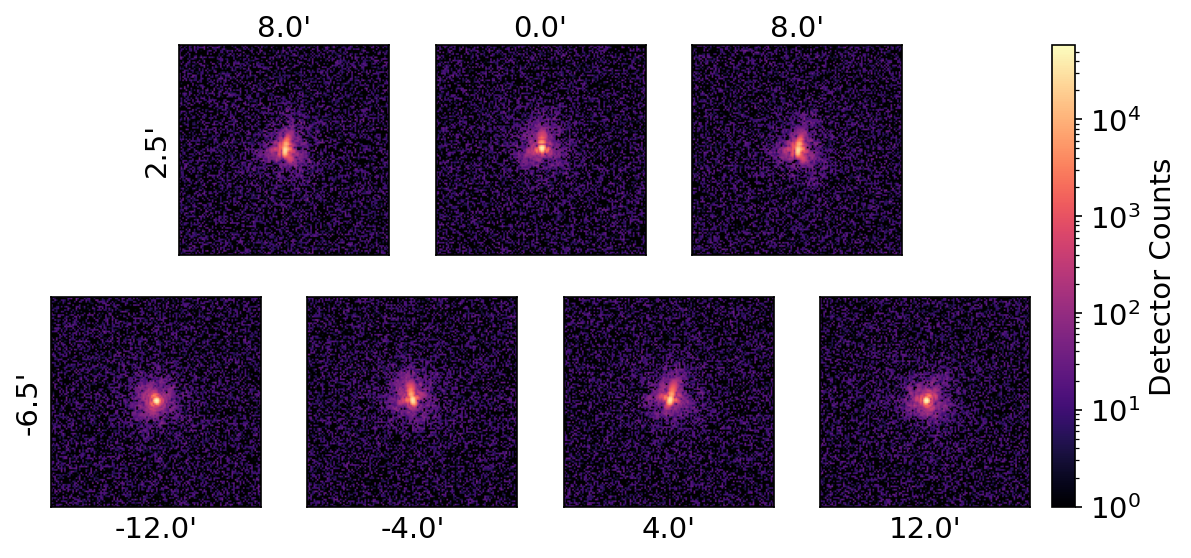

In [77]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## PLOT WFES

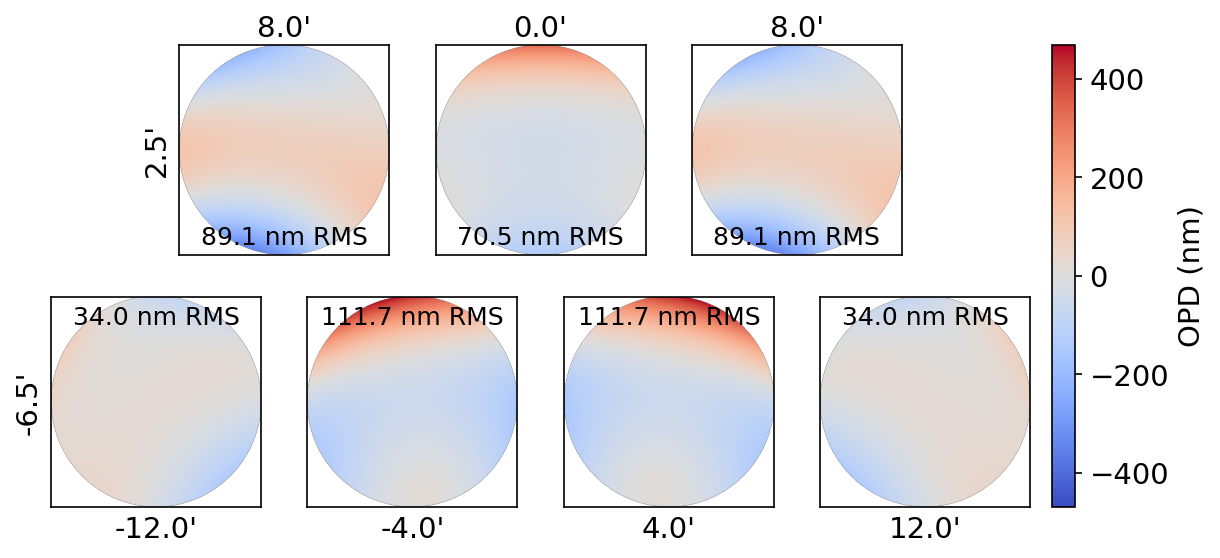

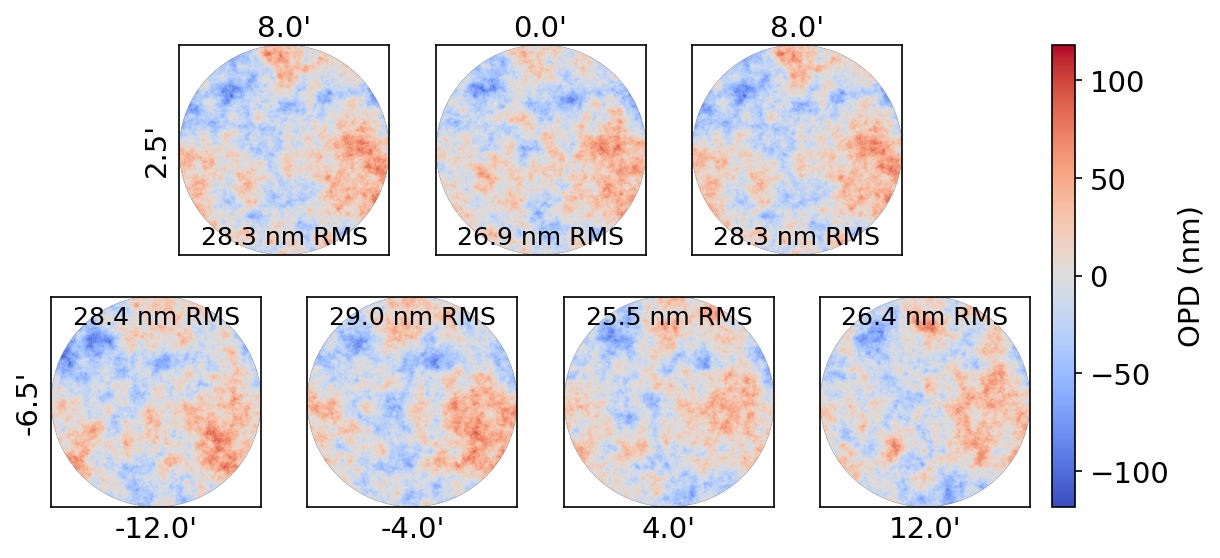

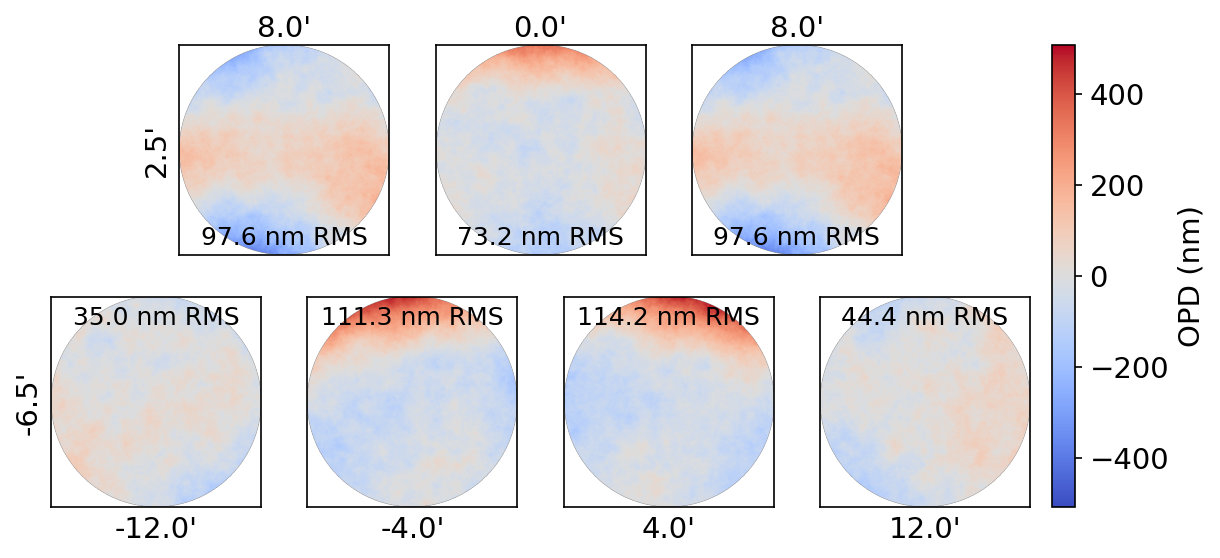

In [78]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

opds_fields_nominal = opds_fields

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## MONTE CARLO

In [79]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignment_cases_100_dec_50um_tilt_5as_wM1.pkl')

In [83]:
# SNR threshold
snr_thresh = 3

# bing bong
max_kicks = 2
iters_bing_bong = 20
iters_psf = 20
max_ls = 30
thresh_minima = 1e-1
frac_conv = 5e-2

# system stuff20
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]
efl = sys.cfg['general']['f_eff']
pupil_dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
focal_dx = sys.cfg['detector']['dx_focal']

# stuff to save
data = {}

case = 1

for m in misalignments:

    print(f'CASE {case:03.0f} ----------------------------------')
    print()

    # apply misalignment
    sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

    # get total OPDs per field
    opds_fields = copy.deepcopy(sys.opds_field)
    opds_optics = copy.deepcopy(sys.opds_optics)
    opds_truths = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

    # calculate RMS of ground truth OPDs per field
    rms_truth_per_field = []
    for opd in opds_truths:
        opd -= np.mean(opd[pupil])
        rms_truth_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    # calculate RMS of diversity per field
    rms_diversity_per_field = []
    for opd in opds_fields_nominal:
        opd -= np.mean(opd[pupil])
        rms_diversity_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    # take images for FFPR
    dark = sys.get_dark(stacked_frames=1)
    images = [im - dark for im in sys.snap(stacked_frames=1)]

    # get image SNRs and filter
    noise_lvl = dark.std()
    filtered_images = []
    snr_per_field = []
    for im in images:
        snr_per_field.append(float(im.max() / dark.std()))
        mask = im > noise_lvl * snr_thresh
        filtered_images.append(im * mask)

    print(f'MEDIAN RMS OPD ACROSS FIELD = {np.median(np.array(rms_truth_per_field)):.2f} nm')
    print(f'MEDIAN IMAGE SNR ACROSS FIELD = {np.median(np.array(snr_per_field)):.1f}')
    print()

    # refresh bing bong things
    count = 1
    bing = 1.
    bong = 1.
    kicks = 0
    pre_kick_f = 1.
    pre_kick_x = 0

    # initialize FFPR
    opt = FFPR2(wvls=sys.wvls.tolist(), amp=sys.pupil, max_zernike=11, fields=fields, divs=opds_fields_nominal, efl=efl, 
                psfs=filtered_images, pupil_dx=pupil_dx, focal_dx=focal_dx, error=gain_invariant_error, jitter_kernel=sys.jitter_kernel)

    # BING BONG
    print('BEGIN BING BONG')

    while True: 
        print('---------------')

        fg = partial(opt.fg, opt_param='common', opt_weights=None)
        x0 = copy.deepcopy(opt.coeffs.get())
        minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
                options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_bing_bong})

        bing = float(opt.costs[-1])
        print(f'BING {count:02.0f} | f = {bing:.2e}')

        if (np.abs(bong - bing) <= (frac_conv * bong)) and bing < thresh_minima:
            print(f'CONVERGED: BING WITHIN {frac_conv * 100:2.0f}% OF BONG, f BELOW {thresh_minima:.2e}')
            print('TERMINATING BING BONG')
            break
        
        fg = partial(opt.fg, opt_param='all', opt_weights=None)
        x0 = np.concatenate((copy.deepcopy(opt.field_terms), copy.deepcopy(opt.coeffs)), axis=0).get()
        minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
                options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_bing_bong})

        bong = float(opt.costs[-1])
        print(f'BONG {count:02.0f} | f = {bong:.2e}')

        if bong < thresh_minima:
            if (np.abs(bing - bong) <= (frac_conv * bing)):
                print(f'CONVERGED: BONG WITHIN {frac_conv * 100:2.0f}% OF BING, f BELOW {thresh_minima:.2e}')
                print('TERMINATING BING BONG')
                break

        if bong > thresh_minima:
            if (np.abs(bing - bong) <= (frac_conv * bing)):
                if bong > pre_kick_f:
                    print('KICK UNSUCCESSFUL, UNKICKING')
                    pre_kick_f = copy.deepcopy(bong)
                    opt.coeffs = pre_kick_x
                else:
                    if kicks == max_kicks:
                        print('NO MORE KICKING, YOU MAY BE COOKED')
                        print('TERMINATING BING BONG')
                        break
                    else:
                        print('STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING')
                        pre_kick_x = copy.deepcopy(opt.coeffs)
                        pre_kick_f = copy.deepcopy(bong)
                        opt.coeffs[2::2] *= -0.5
                        opt.coeffs[1::2] *= -0.5
                        kicks += 1

        count += 1

    print('---------------')
    print('INDIVIDUAL PSF OPTIMIZATION')

    for pdpr in opt.PDPR_list:
        fg = partial(pdpr.fg, opt_param='coeffs', opt_weights=None)
        x0 = pdpr.coeffs.get()

        minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
                options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_psf})

    # for pdpr in opt.PDPR_list:
    #     fg = partial(pdpr.fg, opt_param='map', opt_weights=None)
    #     x0 = pdpr.map.ravel().get()

    #     minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
    #              options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_psf})

    print('---------------')
    print('BING BONG DONE')
    print()

    # calculate estimate residuals
    opds_estimates = [pdpr.models[0].opd + pdpr.models[0].div for pdpr in opt.PDPR_list]
    opds_residuals = [estimate - truth for estimate, truth in zip(opds_estimates, opds_truths)]

    # get RMS of residual per field
    rms_residual_per_field = []
    for opd in opds_residuals:
        opd -= np.mean(opd[pupil])
        rms_residual_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    print(f'MEDIAN RMS RESIDUAL ACROSS FIELD = {np.median(np.array(rms_residual_per_field)):.2f} nm')
    print()
    print()

    # save to data cube
    data.update({f'CASE{case:03.0f}' : {'RMS_TRUTH_PER_FIELD' : rms_truth_per_field,
                                        'RMS_RESIDUAL_PER_FIELD' : rms_residual_per_field,
                                        'RMS_DIVERSITY_PER_FIELD' : rms_diversity_per_field,
                                        'SNR_PER_FIELD' : snr_per_field,
                                        'FIELDS' : fields}})

    case += 1

utils.save_pickle('/home/derbyk/src/ffpr/sim_results/20260503_mc_ffpr_default_mag_15_dec_50um_tilt_5as_wM1_2.pkl', data=data)

CASE 001 ----------------------------------

MEDIAN RMS OPD ACROSS FIELD = 251.10 nm
MEDIAN IMAGE SNR ACROSS FIELD = 884.4

BEGIN BING BONG
---------------
BING 01 | f = 3.96e-01
BONG 01 | f = 3.73e-01
---------------
BING 02 | f = 3.58e-01
BONG 02 | f = 3.54e-01
STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 03 | f = 3.39e-01
BONG 03 | f = 3.13e-01
---------------
BING 04 | f = 3.07e-01
BONG 04 | f = 3.06e-01
STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 05 | f = 4.15e-01
BONG 05 | f = 3.71e-01
---------------
BING 06 | f = 3.56e-01
BONG 06 | f = 3.55e-01
KICK UNSUCCESSFUL, UNKICKING
---------------
BING 07 | f = 3.37e-01
BONG 07 | f = 3.12e-01
---------------
BING 08 | f = 3.06e-01
BONG 08 | f = 3.05e-01
NO MORE KICKING, YOU MAY BE COOKED
TERMINATING BING BONG
---------------
INDIVIDUAL PSF OPTIMIZATION
---------------
BING BONG DONE

MEDIAN RMS RESIDUAL ACROSS FIELD = 1879.22 nm


CASE 002 -------------------------

## VISUALIZE

Text(0.5, 0.98, '100 Misalignment Cases, 94% Convergence Rate\n$\\pm50\\mu m$ Decenter X, Y on M2, M3, M4\n$\\pm5$" Tilt X, Y on M2, M3, M4')

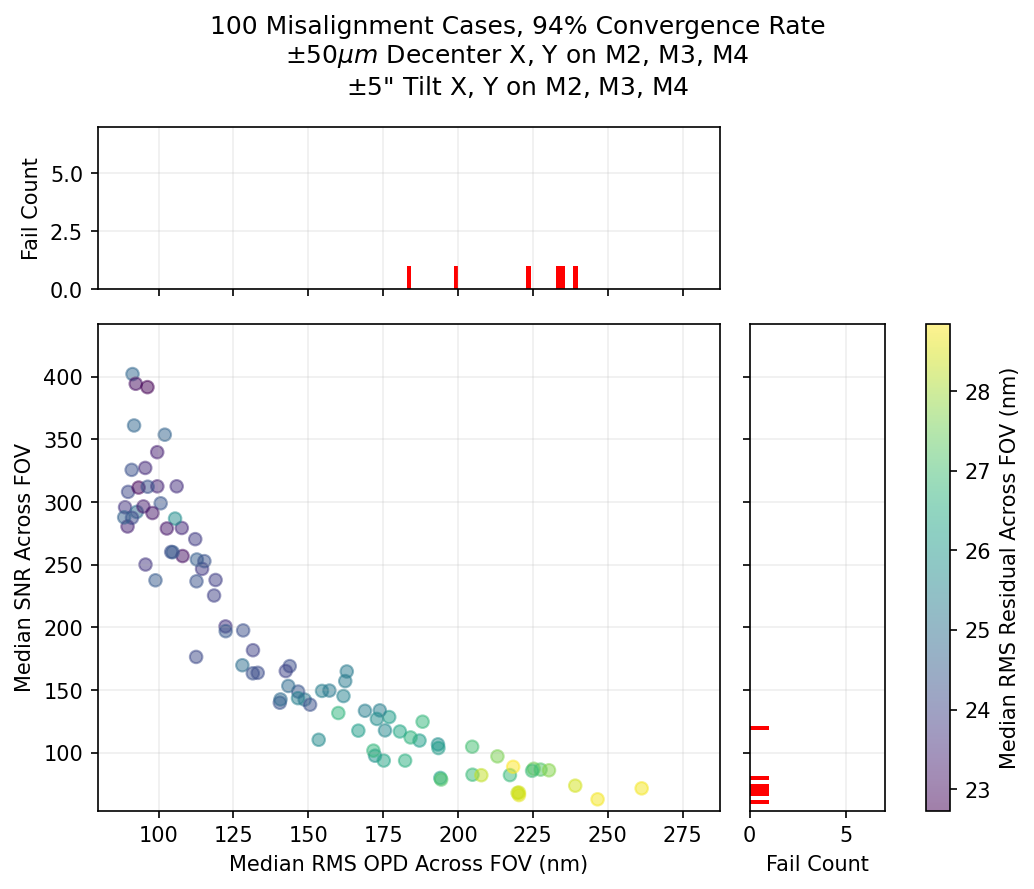

In [112]:
data = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260421_mc_ffpr_default.pkl')

median_rms_truth = np.zeros(len(data))
median_rms_residual = np.zeros(len(data))
max_rms_residual = np.zeros(len(data))
min_rms_residual = np.zeros(len(data))
std_rms_residual = np.zeros(len(data))
median_snr = np.zeros(len(data))

for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(7, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min()
xmax = _np.array([xs.max(), fails_x.max()]).max()

ymin = _np.array([ys.min(), fails_y.min()]).min()
ymax = _np.array([ys.max(), fails_y.max()]).max()

cmin = cs.min()
cmax = cs.max()

# for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
#     if c < 50:
#         count += 1
#         s = axs['scatter'].scatter(x.get(), y.get(), c=c.get(), alpha=0.5,)
#         s.set_clim([20, 50])
#         # plt.colorbar(s)
#     else:
#         fails_x.append(x)
#         fails_y.append(y)

axs['poop'].set_axis_off()

ax = axs['scatter']
s = ax.scatter(xs, ys, c=cs, alpha=0.5)
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD Across FOV (nm)')
ax.set_ylabel('Median SNR Across FOV')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.grid(which='both', alpha=0.2)

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual Across FOV (nm)')


ax = axs['histx']
ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Fail Count')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([0, 7])
ax.grid(which='both', alpha=0.2)

ax = axs['histy']
ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xlabel('Fail Count')
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.set_xlim([0, 7])
ax.grid(which='both', alpha=0.2)


fig.suptitle(f'{len(data):02.0f} Misalignment Cases, {len(cs) / len(data) * 100:02.0f}% Convergence Rate\n$\pm50\mu m$ Decenter X, Y on M2, M3, M4\n$\pm5$" Tilt X, Y on M2, M3, M4')


In [113]:
data = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260503_mc_ffpr_default_mag_17_dec_50um_tilt_5as_wM1.pkl')

In [114]:
median_rms_truth = np.zeros(len(data))
median_rms_residual = np.zeros(len(data))
max_rms_residual = np.zeros(len(data))
min_rms_residual = np.zeros(len(data))
std_rms_residual = np.zeros(len(data))
median_snr = np.zeros(len(data))

for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

Text(0.5, 0.98, '100 Misalignment Cases, 68% Convergence Rate\n$\\pm50\\mu m$ Decenter X, Y on M2, M3, M4\n$\\pm5$" Tilt X, Y on M2, M3, M4')

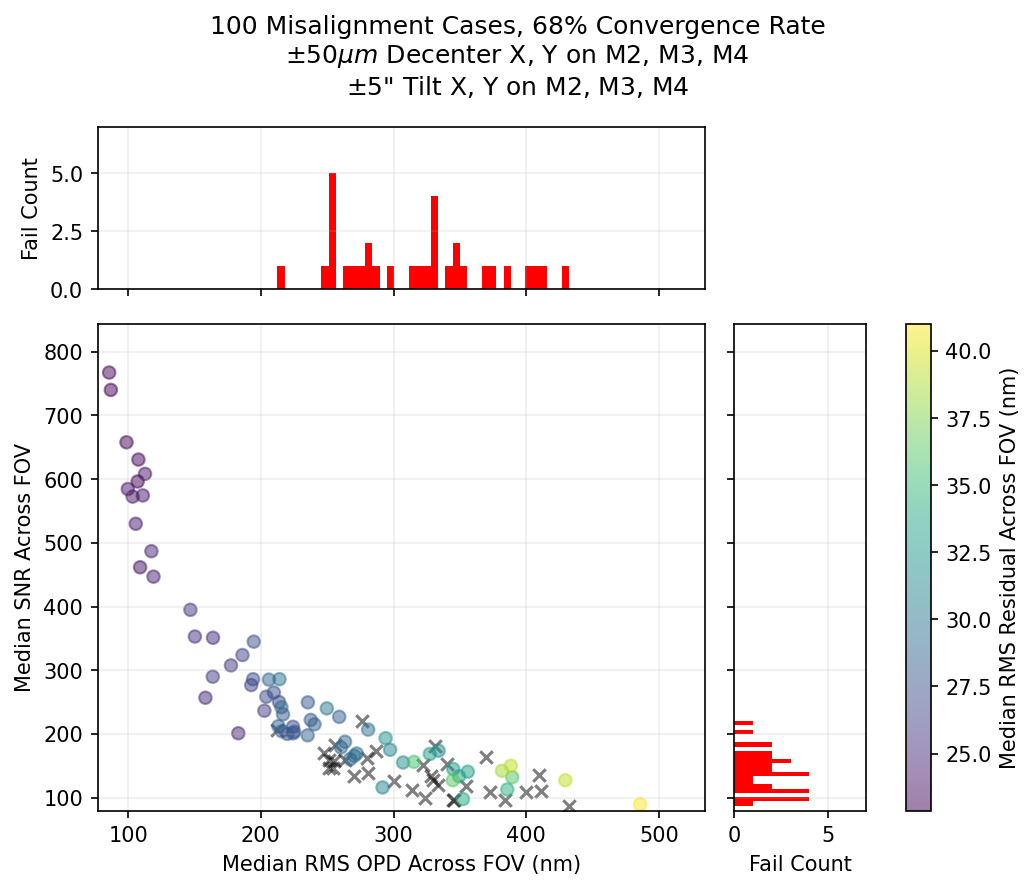

In [117]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(7, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

count = 0
fails_x = []
fails_y = []
fails_c = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))
        fails_c.append(float(c))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)
fails_c = _np.array(fails_c)


xmin = _np.array([xs.min(), fails_x.min()]).min()
xmax = _np.array([xs.max(), fails_x.max()]).max()

ymin = _np.array([ys.min(), fails_y.min()]).min()
ymax = _np.array([ys.max(), fails_y.max()]).max()

cmin = cs.min()
cmax = cs.max()

# for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
#     if c < 50:
#         count += 1
#         s = axs['scatter'].scatter(x.get(), y.get(), c=c.get(), alpha=0.5,)
#         s.set_clim([20, 50])
#         # plt.colorbar(s)
#     else:
#         fails_x.append(x)
#         fails_y.append(y)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='k', alpha=0.5, marker='x')
s = ax.scatter(xs, ys, c=cs, alpha=0.5)
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD Across FOV (nm)')
ax.set_ylabel('Median SNR Across FOV')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.grid(which='both', alpha=0.2)

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual Across FOV (nm)')


ax = axs['histx']
ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Fail Count')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([0, 7])
ax.grid(which='both', alpha=0.2)

ax = axs['histy']
ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xlabel('Fail Count')
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.set_xlim([0, 7])
ax.grid(which='both', alpha=0.2)


fig.suptitle(f'{len(data):02.0f} Misalignment Cases, {len(cs) / len(data) * 100:02.0f}% Convergence Rate\n$\pm50\mu m$ Decenter X, Y on M2, M3, M4\n$\pm5$" Tilt X, Y on M2, M3, M4')


Text(0.5, 0.98, '100 Misalignment Cases, 68% Convergence Rate\n$\\pm50\\mu m$ Decenter X, Y on M2, M3, M4\n$\\pm5$" Tilt X, Y on M2, M3, M4')

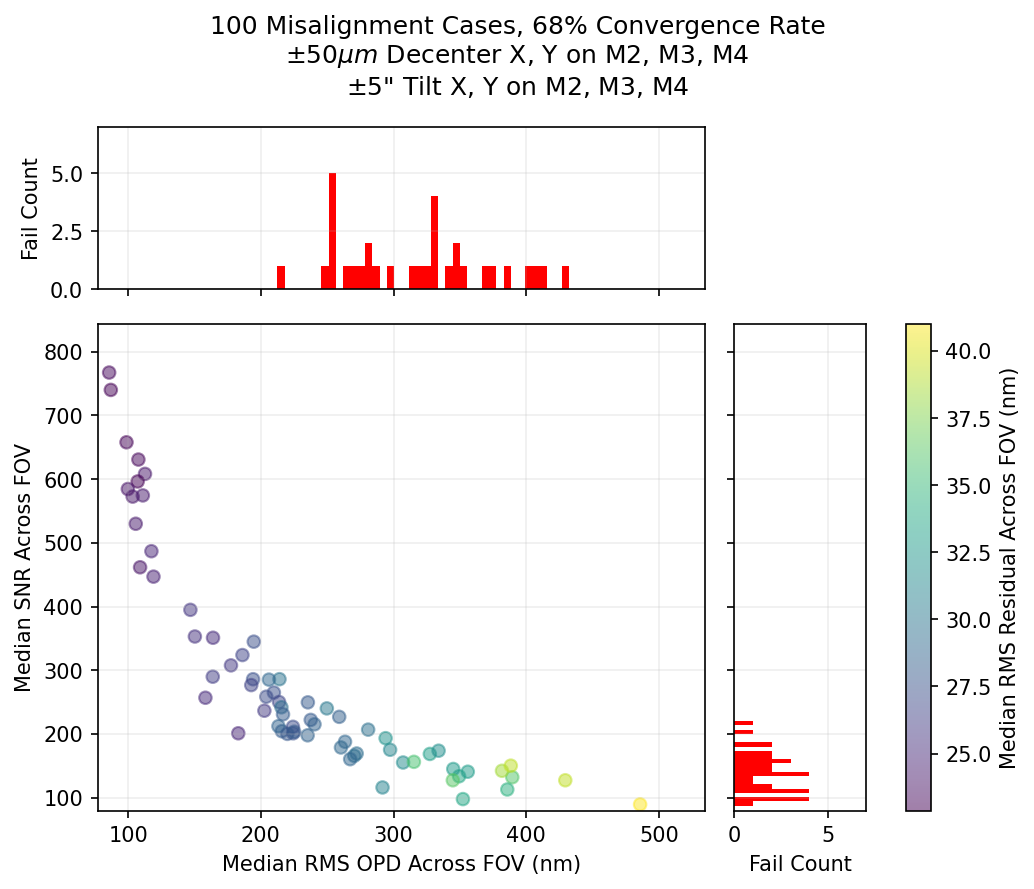

In [111]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(7, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min()
xmax = _np.array([xs.max(), fails_x.max()]).max()

ymin = _np.array([ys.min(), fails_y.min()]).min()
ymax = _np.array([ys.max(), fails_y.max()]).max()

cmin = cs.min()
cmax = cs.max()

# for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
#     if c < 50:
#         count += 1
#         s = axs['scatter'].scatter(x.get(), y.get(), c=c.get(), alpha=0.5,)
#         s.set_clim([20, 50])
#         # plt.colorbar(s)
#     else:
#         fails_x.append(x)
#         fails_y.append(y)

axs['poop'].set_axis_off()

ax = axs['scatter']
s = ax.scatter(xs, ys, c=cs, alpha=0.5)
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD Across FOV (nm)')
ax.set_ylabel('Median SNR Across FOV')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.grid(which='both', alpha=0.2)

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual Across FOV (nm)')


ax = axs['histx']
ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Fail Count')
ax.set_xlim([xmin * 0.9, xmax * 1.1])
ax.set_ylim([0, 7])
ax.grid(which='both', alpha=0.2)

ax = axs['histy']
ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xlabel('Fail Count')
ax.set_ylim([ymin * 0.9, ymax * 1.1])
ax.set_xlim([0, 7])
ax.grid(which='both', alpha=0.2)


fig.suptitle(f'{len(data):02.0f} Misalignment Cases, {len(cs) / len(data) * 100:02.0f}% Convergence Rate\n$\pm50\mu m$ Decenter X, Y on M2, M3, M4\n$\pm5$" Tilt X, Y on M2, M3, M4')


Text(0.5, 0.98, '100 Misalignment Cases, 68% Convergence Rate\n$\\pm50\\mu m$ Decenter X, Y on M2, M3, M4\n$\\pm5$" Tilt X, Y on M2, M3, M4')

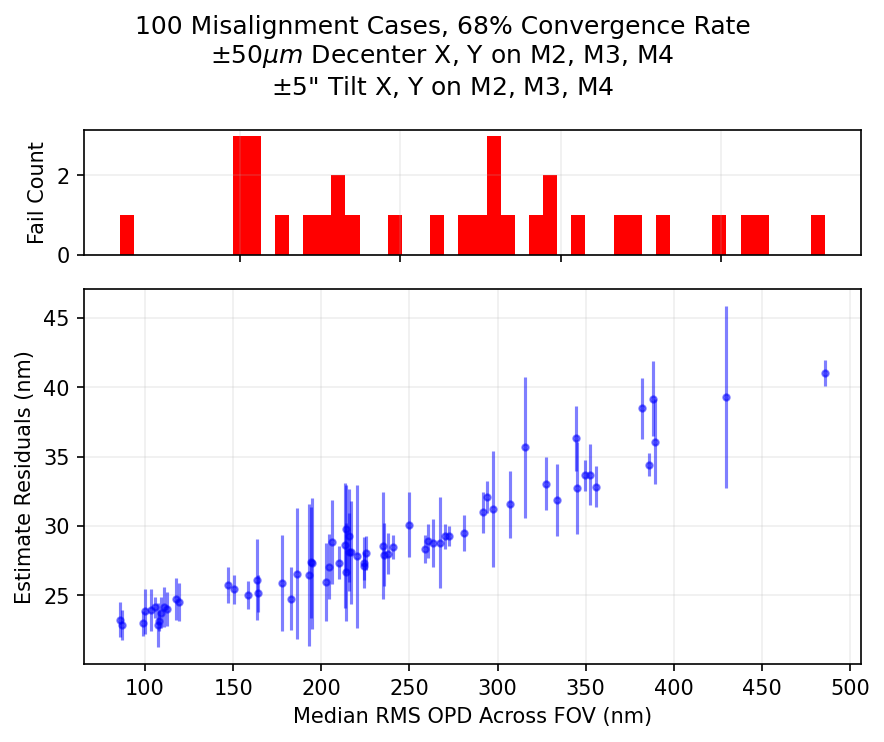

In [ ]:
fig, axs = plt.subplot_mosaic([['histx'],
                               ['errbar']],
                               figsize=(6, 5), 
                               height_ratios=[1, 3],
                               layout='tight',
                               dpi=150)

count = 0
fails = []

# for x, y, h, l in zip(median_rms_truth, median_rms_residual, max_rms_residual, min_rms_residual):
#     if y < 50:
#         count += 1
        # plt.errorbar(x.get(), y.get(), yerr=[[h.get() - y.get()], [y.get() - l.get()]], fmt='.', alpha=0.5, color='b')

for x, y, s in zip(median_rms_truth, median_rms_residual, std_rms_residual):
    if y < 100:
        count += 1
        axs['errbar'].errorbar(x.get(), y.get(), yerr=s.get(), fmt='.', alpha=0.5, color='b')
    else:
        fails.append(x)

ax = axs['errbar']
ax.set_xlabel('Median RMS OPD Across FOV (nm)')
ax.set_ylabel('Estimate Residuals (nm)')
# ax.set_xlim([85, 265])
# ax.set_ylim([0, 40])
ax.grid(which='both', alpha=0.2)

ax = axs['histx']
ax.hist(np.array(fails).get(), bins=50, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Fail Count')
# ax.set_xlim([85, 265])
# ax.set_ylim([0, 2])
ax.grid(which='both', alpha=0.2)

fig.suptitle(f'{len(data):02.0f} Misalignment Cases, {count / len(data) * 100:02.0f}% Convergence Rate\n$\pm50\mu m$ Decenter X, Y on M2, M3, M4\n$\pm5$" Tilt X, Y on M2, M3, M4')
